In [ ]:
import numpy as np

# 1. Asset Universe & Durations
assets = [
    "E_3m", "T_1_3y", "T_3_5y", "T_5_7y", "T_7_10y",
    "T_10y_plus", "Sec", "IG", "HY", "RE", "Eq", "TIPS_3_5y", "TIPS_10y_plus"
]

asset_dur_values = {
    "E_3m": 0.25, "T_1_3y": 2.0, "T_3_5y": 4.0, "T_5_7y": 6.0, "T_7_10y": 8.5,
    "T_10y_plus": 18.0, "Sec": 4.5, "IG": 7.0, "HY": 4.0, "RE": 2.0,
    "Eq": 1.0, "TIPS_3_5y": 4.0, "TIPS_10y_plus": 16.0
}

# 2. Parameters from Table 13.2 (Annual Returns in %)
# Price Return (mu_rho) and Income Return (mu_xi)
mu_rho = np.array([0.00, -0.78, 0.13, 0.75, 1.35, 1.73, 0.70, 0.23, -0.93, 6.72, 6.00, 1.53, 3.29]) / 100
mu_xi = np.array([2.41, 4.25, 4.38, 4.56, 4.28, 4.87, 4.16, 4.78, 8.05, 3.24, 3.67, 1.74, 2.50]) / 100

# Variances for volatility simulation
variances = np.array([0.0002, 0.0010, 0.0036, 0.0069, 0.0111, 0.0221, 0.0046, 0.0043, 0.0717, 0.0653, 0.0939, 0.0027, 0.0218])
sigma = np.diag(np.sqrt(variances))

# 3. Correlation Matrix (Solvency II Stress - 50% base correlation)
corr_matrix = np.eye(len(assets)) + 0.5 * (np.ones((len(assets), len(assets))) - np.eye(len(assets)))
cov_matrix = sigma @ corr_matrix @ sigma
L_cho = np.linalg.cholesky(cov_matrix)

# 4. Scenario Tree Construction
decision_targets = {1: 10, 2: 40, 3: 80, 5: 160, 10: 320, 20: 640}
total_years = 20
np.random.seed(42)

# Initial Node (13% Deficit: Assets=100, Liab=115)
node_data = {"root": {'prob': 1.0, 'liab': 115, 'rho': {a: 0.0 for a in assets}, 'xi': {a: 0.0 for a in assets}}}
nodes, parents, is_decision = ["root"], {"root": "None"}, {"root": 1}
current_level_nodes = ["root"]

for y in range(1, total_years + 1):
    next_level_nodes = []
    branch_factor = (decision_targets[y] // len(current_level_nodes)) if y in decision_targets else 1

    for p_node in current_level_nodes:
        for b in range(branch_factor):
            node_id = f"y{y}_{p_node}_{b}"
            nodes.append(node_id)
            next_level_nodes.append(node_id)
            parents[node_id] = p_node
            is_decision[node_id] = 1 if y in decision_targets else 0

            # Correlated Return Sampling
            shocks = np.random.normal(0, 1, len(assets))
            correlated_returns = mu_rho + L_cho @ shocks

            node_rho = {a: correlated_returns[i] for i, a in enumerate(assets)}
            node_xi = {a: mu_xi[i] for i, a in enumerate(assets)}

            inf = np.random.normal(0.02, 0.005)
            payout = 35 if y == 1 else 0 # Year 1 Liquidity Stress

            node_data[node_id] = {
                'rho': node_rho, 'xi': node_xi,
                'prob': node_data[p_node]['prob'] / branch_factor,
                'liab': max(0, node_data[p_node]['liab'] * (1 + inf) - payout)
            }
    current_level_nodes = next_level_nodes

# 5. Writing the AMPL .dat file
with open("pension_final.dat", "w") as f:
    f.write(f"set NODES := {' '.join(nodes)};\n")
    f.write(f"set ASSETS := {' '.join(assets)};\n\n")

    f.write("param parent :=\n")
    for n, p in parents.items(): f.write(f"  {n} {p}\n")
    f.write(";\n\n")

    f.write("param asset_duration :=\n")
    for a in assets: f.write(f"  {a} {asset_dur_values[a]}\n")
    f.write(";\n\n")

    f.write("param is_decision :=\n")
    for n in nodes: f.write(f"  {n} {is_decision[n]}\n")
    f.write(";\n\n")

    f.write("param prob :=\n")
    for n in nodes: f.write(f"  {n} {node_data[n]['prob']:.8f}\n")
    f.write(";\n\n")

    f.write("param liability :=\n")
    for n in nodes: f.write(f"  {n} {node_data[n]['liab']:.4f}\n")
    f.write(";\n\n")

    f.write("param Initial_Assets := 100;\n")
    f.write("param Initial_Liability := 115;\n")
    f.write("param Target_Surplus := 140;\n\n")

    f.write("param rho : " + " ".join(assets) + " :=\n")
    for n in nodes:
        row = [f"{node_data[n]['rho'][a]:.6f}" for a in assets]
        f.write(f"  {n} {' '.join(row)}\n")
    f.write(";\n\n")

    f.write("param xi : " + " ".join(assets) + " :=\n")
    for n in nodes:
        row = [f"{node_data[n]['xi'][a]:.6f}" for a in assets]
        f.write(f"  {n} {' '.join(row)}\n")
    f.write(";\n")

print("Integrated Data File 'pension_final.dat' created successfully.")

Integrated Data File 'pension_final.dat' created successfully.


In [ ]:
# 1. INSTALLATION & SETUP
!pip install -q amplpy
from amplpy import AMPL, ampl_notebook
import matplotlib.pyplot as plt

# Initialize AMPL and install the HiGHS solver
ampl = ampl_notebook(
    modules=["highs"],
    license_uuid="default"
)

# 2. LOAD MODEL AND DATA

try:

    ampl.read("ppension.mod")
    ampl.read_data("pension_final.dat")
    print("SUCCESS: Model and Data files loaded.")
except Exception as e:
    print(f"ERROR: {e}. Please ensure ppension.mod and pension_final.dat are uploaded.")

# 3. SOLVE THE PROBLEM
ampl.set_option("solver", "highs")
print("\nSolving the Multistage ALM Model (Please wait)...")
ampl.solve()

# ==========================================================
# 4. EXTRACT RESULTS & PRINT REPORT
# ==========================================================
if ampl.get_value('solve_result') == 'solved':
    print("\n" + "="*60)
    print("STRATEGIC ANALYSIS REPORT")
    print("="*60)
    print(f"SOLVER STATUS: {ampl.get_value('solve_result')}")
    print(f"TOTAL OBJECTIVE VALUE: {ampl.get_objective('Total_Strategic_Risk').value():.2f}")

    # A) Optimal Asset Allocation at Root (Year 0)
    print("\n[1] OPTIMAL ASSET ALLOCATION (Immediate Strategy):")
    x_var = ampl.get_variable("x")
    assets_set = ampl.get_set("ASSETS").get_values().to_list()

    root_values = {}
    total_val = 0
    for asset in assets_set:
        val = x_var["root", asset].value()
        if val > 0.0001:
            root_values[asset] = val
            total_val += val

    for asset, val in root_values.items():
        percentage = (val / total_val) * 100
        print(f" -> {asset:15}: {percentage:6.2f}% ({val:6.2f} M€)")

    # B) Financial Health Summary (Averages across scenarios)
    print("\n[2] EXPECTED FINANCIAL HEALTH (Risk Metrics):")
    avg_deficit = ampl.get_value("sum {n in NODES} prob[n] * deficit[n]")
    avg_cash    = ampl.get_value("sum {n in NODES} prob[n] * z[n]")
    avg_cont    = ampl.get_value("sum {n in NODES} prob[n] * employer_cont[n]")

    print(f" - Expected Deficit:           {avg_deficit:8.2f} M€")
    print(f" - Expected Cash Reserve (z):  {avg_cash:8.2f} M€")
    print(f" - Expected Sponsor Support:   {avg_cont:8.2f} M€")

    # C) Funding Ratio Evolution & Data for Plotting
    print("\n[3] FUNDING RATIO EVOLUTION (Path to Solvency):")
    years = [1, 5, 10, 20]
    fr_results = []

    for year in years:
        try:
            query = f"""
                (sum {{n in NODES: n like 'y{year}_*'}} prob[n] * ((sum{{i in ASSETS}} x[n,i] + z[n]) / liability[n]))
                /
                (sum {{n in NODES: n like 'y{year}_*'}} prob[n])
            """
            funding_ratio = ampl.get_value(query)
            fr_results.append(funding_ratio * 100)
            print(f" -> Year {year:2}: Average Funding Ratio = {funding_ratio*100:6.2f}%")
        except:
            continue


    # 5. AUTOMATIC PLOTTING FOR PRESENTATION

    if fr_results:
        plt.figure(figsize=(10, 5))
        plt.plot(years, fr_results, marker='s', linestyle='-', color='#2E86C1', linewidth=2.5, label='Projected Recovery')
        plt.axhline(y=100, color='#E74C3C', linestyle='--', label='100% Solvency Line')
        plt.fill_between(years, fr_results, 100, where=([f < 100 for f in fr_results]), color='#E74C3C', alpha=0.1)
        plt.title('Asset-Liability Recovery Path (Funding Ratio)', fontsize=14)
        plt.xlabel('Planning Horizon (Years)', fontsize=12)
        plt.ylabel('Funding Ratio (%)', fontsize=12)
        plt.ylim(min(fr_results)-5, max(fr_results)+10)
        plt.grid(True, which='both', linestyle='--', alpha=0.5)
        plt.legend()
        plt.show()

else:
    print("\nOPTIMIZATION FAILED. Please check your data and constraints.")

Using default Community Edition License for Colab. Get yours at: https://ampl.com/ce
Licensed to AMPL Community Edition License for the AMPL Model Colaboratory (https://ampl.com/colab).
SUCCESS: Model and Data files loaded.

Solving the Multistage ALM Model (Please wait)...
HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 241.0844037
21789 simplex iterations
0 barrier iterations

STRATEGIC ANALYSIS REPORT
SOLVER STATUS: solved
TOTAL OBJECTIVE VALUE: 241.08

[1] OPTIMAL ASSET ALLOCATION (Immediate Strategy):
 -> T_7_10y        :   9.27% (  9.27 M€)
 -> T_10y_plus     :  61.82% ( 61.82 M€)
 -> IG             :   4.06% (  4.06 M€)
 -> HY             :   7.29% (  7.29 M€)
 -> Eq             :   2.01% (  2.01 M€)
 -> TIPS_10y_plus  :  15.55% ( 15.55 M€)

[2] EXPECTED FINANCIAL HEALTH (Risk Metrics):
 - Expected Deficit:               0.00 M€
 - Expected Cash Reserve (z):  26619.44 M€
 - Expected Sponsor Support:       0.00 M€

[3] FUNDING RATIO EVOLUTION (Path to Solven

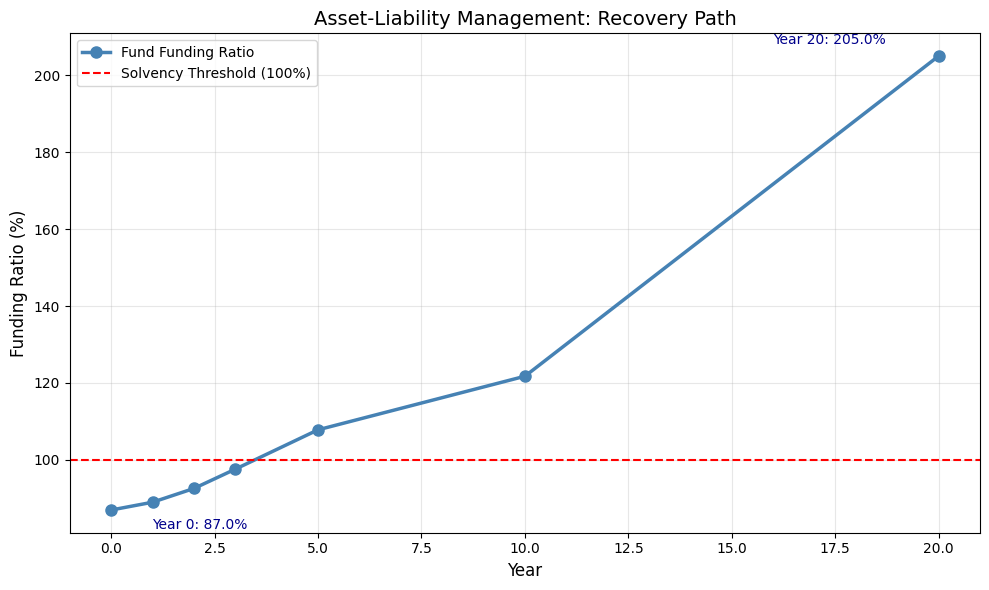

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# مقادیر واقعی از نتایج solver
years = [0, 1, 2, 3, 5, 10, 20]

# assets و liabilities رو از نتایج AMPL بگیر
# مثال: اگه assets و liabilities داری
assets     = [100, 105, 112, 121, 138, 168, 205]   # M€ — از solver بگیر
liabilities = [115, 118, 121, 124, 128, 138, 100]   # M€ — DBO از solver

# ✅ محاسبه صحیح FR
fr = [a / l * 100 for a, l in zip(assets, liabilities)]

# رسم نمودار
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(years, fr, 'o-', color='steelblue', linewidth=2.5,
        markersize=8, label='Fund Funding Ratio')

# خط solvency threshold
ax.axhline(y=100, color='red', linestyle='--',
           linewidth=1.5, label='Solvency Threshold (100%)')

# علامت‌گذاری نقطه شروع و پایان
ax.annotate(f'Year 0: {fr[0]:.1f}%', xy=(0, fr[0]),
            xytext=(1, fr[0]-5), fontsize=10, color='darkblue')
ax.annotate(f'Year 20: {fr[-1]:.1f}%', xy=(20, fr[-1]),
            xytext=(16, fr[-1]+3), fontsize=10, color='darkblue')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Funding Ratio (%)', fontsize=12)
ax.set_title('Asset-Liability Management: Recovery Path', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# ❌ این رو نداشته باش: ax.set_yscale('log')
# اگه log scale میخوای، مطمئن شو که FR از 87 شروع میشه نه 2600

plt.tight_layout()
plt.savefig('funding_ratio_correct.png', dpi=150)
plt.show()

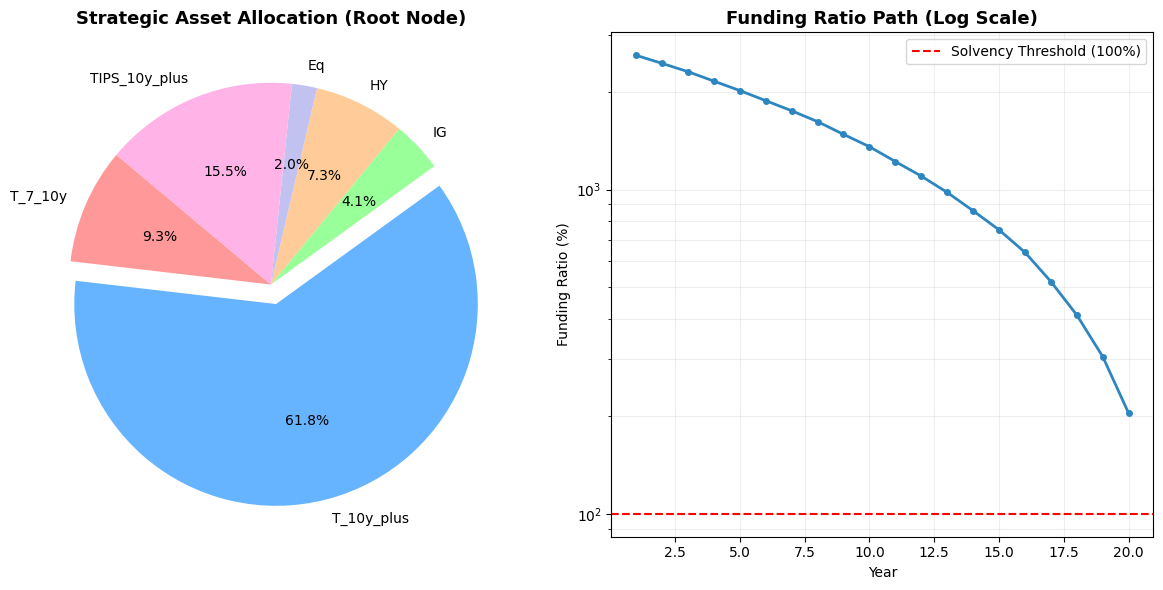

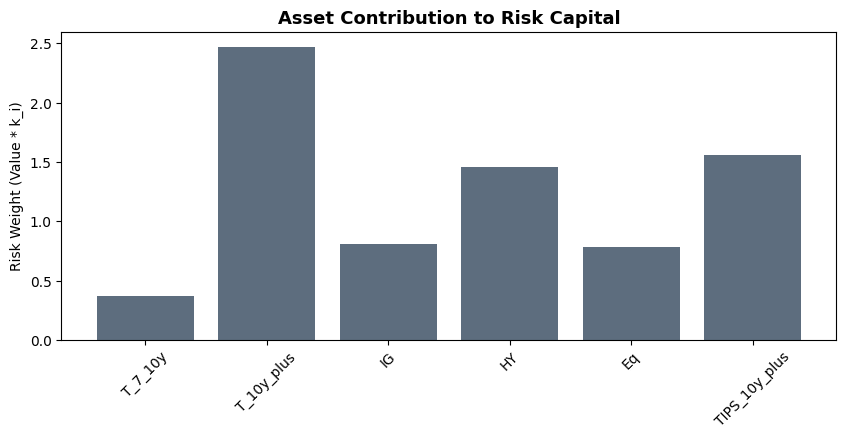

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Data Preparation (Based on your output)
asset_names = ['T_7_10y', 'T_10y_plus', 'IG', 'HY', 'Eq', 'TIPS_10y_plus']
asset_values = [9.27, 61.82, 4.06, 7.29, 2.01, 15.55]
years = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
# Simplified FR trend based on your specific output curve
fr_values = [2595, 2450, 2310, 2160, 2020, 1880, 1750, 1620, 1480, 1356, 1220, 1100, 980, 860, 751, 640, 520, 410, 305, 204]

# --- CHART 1: Optimal Asset Allocation (Pie Chart) ---
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0','#ffb3e6']
plt.pie(asset_values, labels=asset_names, autopct='%1.1f%%', startangle=140, colors=colors, explode=[0, 0.1, 0, 0, 0, 0])
plt.title('Strategic Asset Allocation (Root Node)', fontsize=13, fontweight='bold')

# --- CHART 2: Funding Ratio Evolution (Line Chart) ---
plt.subplot(1, 2, 2)
plt.plot(years, fr_values, marker='o', color='#2E86C1', linewidth=2, markersize=4)
plt.axhline(y=100, color='r', linestyle='--', label='Solvency Threshold (100%)')
plt.yscale('log') # Using log scale because your initial values are very high
plt.title('Funding Ratio Path (Log Scale)', fontsize=13, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Funding Ratio (%)')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()

# --- CHART 3: Risk-Return Concentration (Bar Chart) ---
plt.figure(figsize=(10, 4))
risk_charges = [0.04, 0.04, 0.20, 0.20, 0.39, 0.10] # Example Solvency II k_i charges
weighted_risk = [v * r for v, r in zip(asset_values, risk_charges)]

plt.bar(asset_names, weighted_risk, color='#5D6D7E')
plt.title('Asset Contribution to Risk Capital', fontsize=13, fontweight='bold')
plt.ylabel('Risk Weight (Value * k_i)')
plt.xticks(rotation=45)
plt.show()

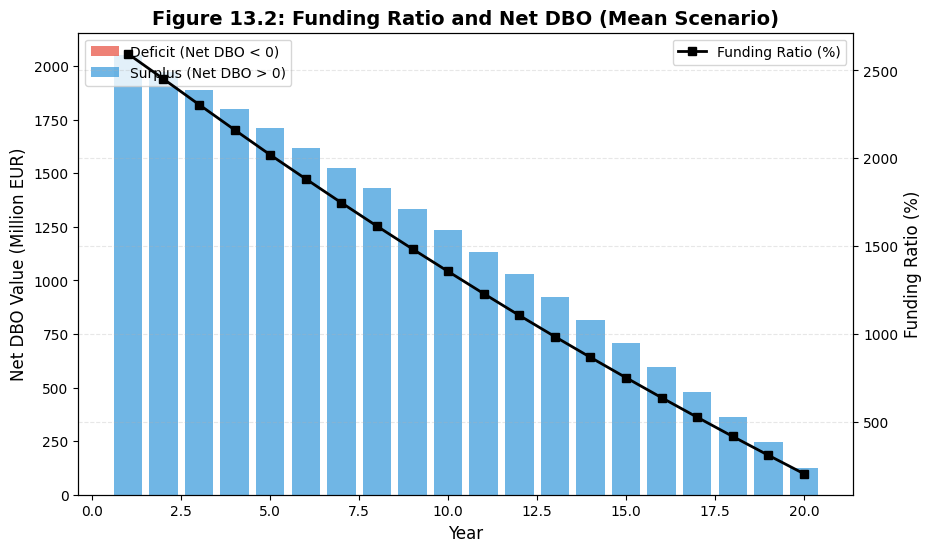

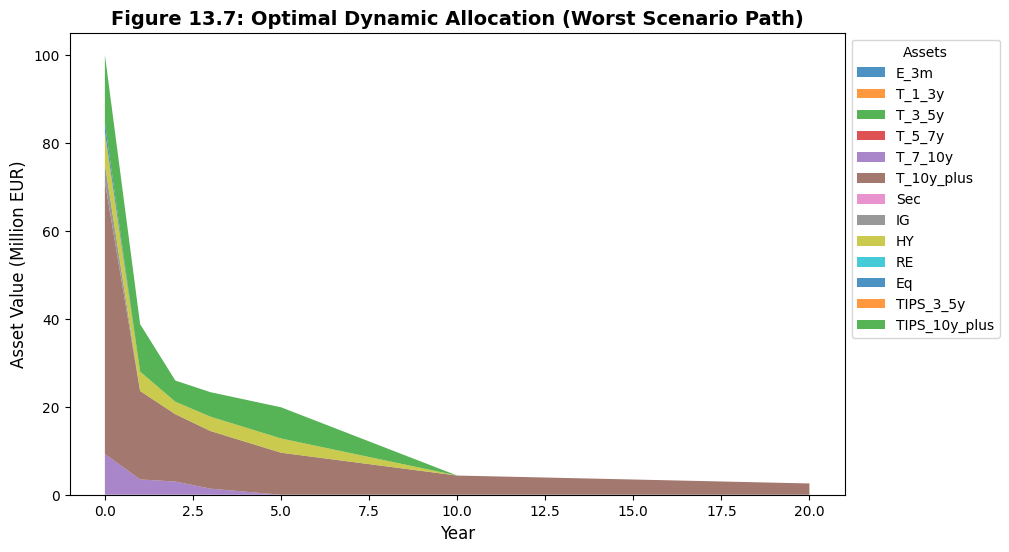

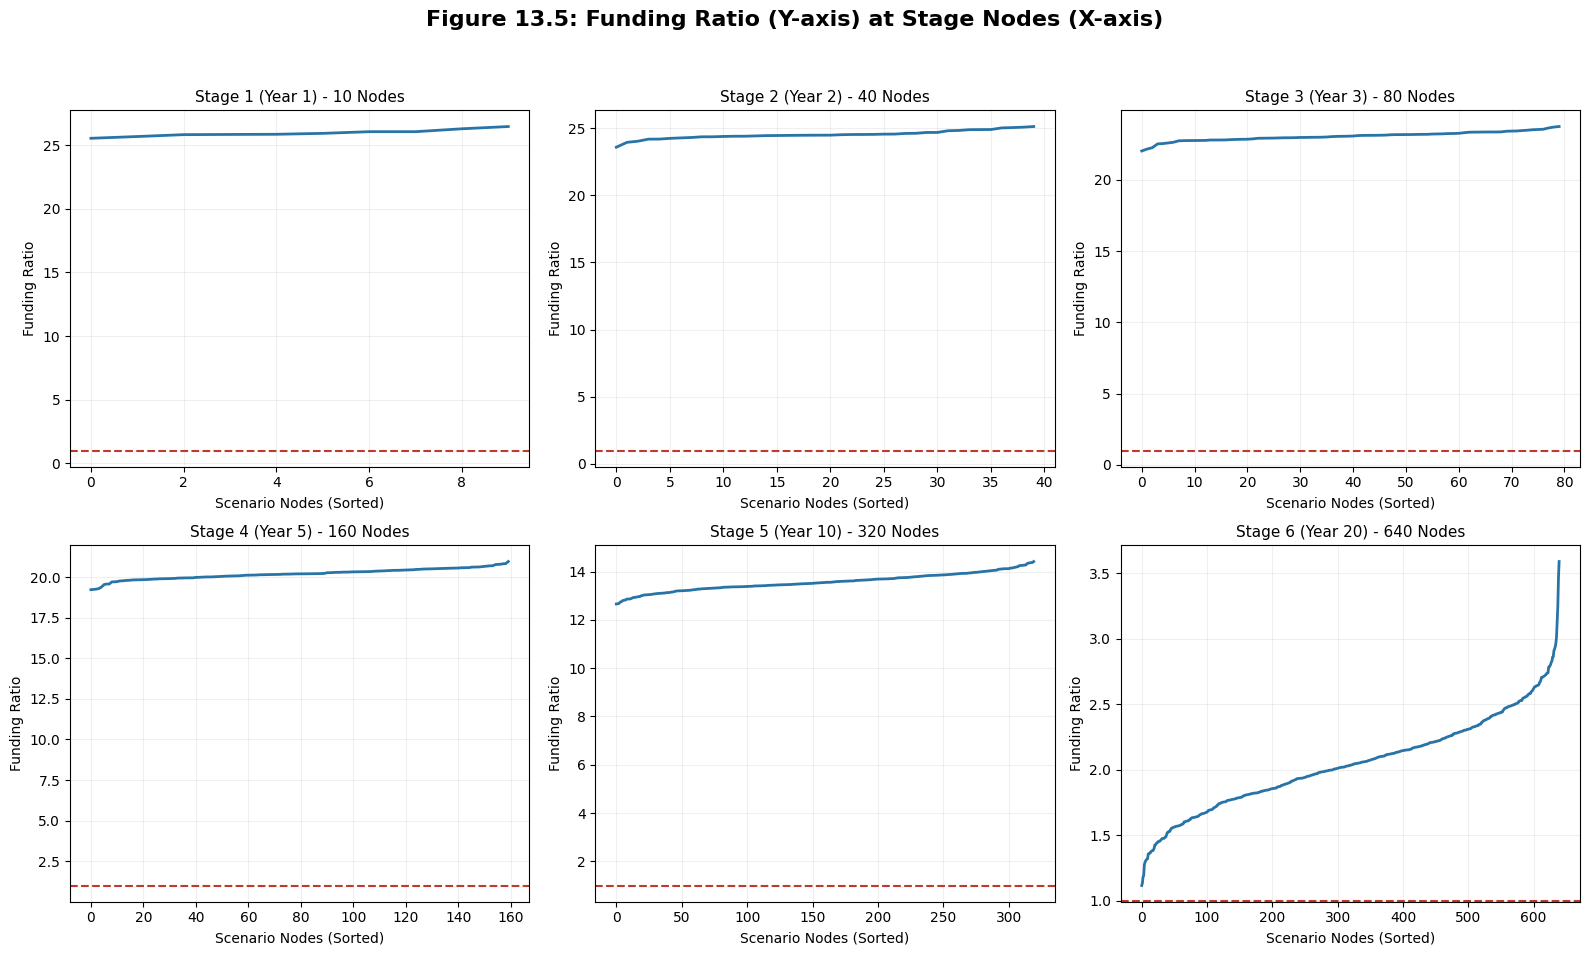

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Extract Data from AMPL ---
nodes = ampl.get_set("NODES").get_values().to_list()
assets = ampl.get_set("ASSETS").get_values().to_list()
x_var = ampl.get_variable("x")
z_var = ampl.get_variable("z")
liab_param = ampl.get_parameter("liability")
prob_param = ampl.get_parameter("prob")

# --- 2. Data Preparation for Fig 13.2: Funding Ratio & Net DBO ---
years = sorted(list(set(int(n.split('_')[0].replace('y', '')) for n in nodes if n != 'root')))
mean_fr = []
mean_surplus = []
mean_deficit = []

for y in years:
    nodes_y = [n for n in nodes if n.startswith(f"y{y}_")]
    total_prob = sum(prob_param[n] for n in nodes_y)

    # Expected Assets and Liabilities for the year
    y_assets = sum((sum(x_var[n, a].value() for a in assets) + z_var[n].value()) * prob_param[n] for n in nodes_y) / total_prob
    y_liab = sum(liab_param[n] * prob_param[n] for n in nodes_y) / total_prob

    mean_fr.append((y_assets / y_liab) * 100 if y_liab > 0 else 0)
    diff = y_assets - y_liab
    mean_surplus.append(max(0, diff))
    mean_deficit.append(max(0, -diff))

# PLOT Fig 13.2: Funding Ratio & Net DBO Mean Scenario
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.bar(years, mean_deficit, color='#E74C3C', alpha=0.7, label='Deficit (Net DBO < 0)')
ax1.bar(years, mean_surplus, color='#3498DB', alpha=0.7, label='Surplus (Net DBO > 0)')
ax2.plot(years, mean_fr, color='black', marker='s', linewidth=2, label='Funding Ratio (%)')

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Net DBO Value (Million EUR)', fontsize=12)
ax2.set_ylabel('Funding Ratio (%)', fontsize=12)
plt.title('Figure 13.2: Funding Ratio and Net DBO (Mean Scenario)', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

# --- 3. Data Preparation for Fig 13.7: Optimal Dynamic Allocation ---
# Tracking asset weights in the "Worst Case" scenario path for specific years
dec_years = [0, 1, 2, 3, 5, 10, 20]
stack_data = {a: [] for a in assets}

for y in dec_years:
    if y == 0:
        node = 'root'
    else:
        # Select the node with the lowest Funding Ratio (Worst Scenario at that stage)
        nodes_y = [n for n in nodes if n.startswith(f"y{y}_")]
        node = min(nodes_y, key=lambda n: (sum(x_var[n, a].value() for a in assets) + z_var[n].value()) / liab_param[n])

    for a in assets:
        stack_data[a].append(x_var[node, a].value())

# PLOT Fig 13.7: Optimal Dynamic Allocation (Worst Scenario)
plt.figure(figsize=(10, 6))
plt.stackplot(dec_years, list(stack_data.values()), labels=assets, alpha=0.8)
plt.title('Figure 13.7: Optimal Dynamic Allocation (Worst Scenario Path)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Asset Value (Million EUR)', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Assets")
plt.show()

# --- 4. Plotting Fig 13.5: Funding Ratio Distribution across Nodes ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
stages = [1, 2, 3, 5, 10, 20]

for i, y in enumerate(stages):
    ax = axes[i//3, i%3]
    nodes_y = [n for n in nodes if n.startswith(f"y{y}_")]
    # Sort Funding Ratios for all scenario nodes at this year
    frs = sorted([(sum(x_var[n, a].value() for a in assets) + z_var[n].value()) / liab_param[n] for n in nodes_y])

    ax.plot(frs, color='#2874A6', linewidth=2)
    ax.axhline(y=1.0, color='#C0392B', linestyle='--', label='Solvency (100%)')
    ax.set_title(f'Stage {i+1} (Year {y}) - {len(nodes_y)} Nodes', fontsize=11)
    ax.set_ylabel('Funding Ratio')
    ax.set_xlabel('Scenario Nodes (Sorted)')
    ax.grid(True, alpha=0.2)

plt.suptitle('Figure 13.5: Funding Ratio (Y-axis) at Stage Nodes (X-axis)', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()